# 05 — Baseline Models

Fair bi-temporal baselines for the Sentinel-2 semantic land-cover change project.

**Fixed setup:** v4 dataset; 2020 and 2025 inputs are 9 channels each; 128×128 patches; existing 704/144/160 split; 16 transition classes; 2 binary-change classes; ignore value 255.

Models: Early-Fusion CNN, Siamese CNN, Siamese U-Net. BT-SSSCNet is intentionally excluded from this notebook.

In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SEED=42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
BASE="/kaggle/input/datasets/mssamiksha30/sentinel2-lulc-change-detection/sentinel2_lulc_change_dataset_v4"
PATCH="${BASE}/patches".replace("${BASE}",BASE)
META=os.path.join(BASE,"metadata","patch_metadata.csv")
D20=os.path.join(PATCH,"2020"); D25=os.path.join(PATCH,"2025")
DT=os.path.join(PATCH,"transition_labels"); DC=os.path.join(PATCH,"change_labels")
PS=128; C=9; NT=16; NC=2; IGN=255
BATCH=8; EPOCHS=20; LR=1e-3
OUT="/kaggle/working/baseline_results"; MODELS=os.path.join(OUT,"models"); RESULTS=os.path.join(OUT,"results"); VIS=os.path.join(OUT,"visuals")
for d in [MODELS,RESULTS,VIS]: os.makedirs(d,exist_ok=True)
print(tf.__version__, tf.config.list_physical_devices('GPU'))

2.20.0 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
metadata=pd.read_csv(META)
assert list(metadata.columns)==['patch_id','parent_tile','split']
assert len(metadata)==1008
assert metadata['split'].value_counts().to_dict()=={'train':704,'test':160,'validation':144}
metadata['filename']=metadata.patch_id.astype(str)+'.npy'
for name,d in [('2020',D20),('2025',D25),('transition',DT),('change',DC)]:
    files={f for f in os.listdir(d) if f.endswith('.npy')}
    assert len(files)==1008 and files==set(metadata.filename), name
print('✓ metadata and patch IDs verified')
for f in [metadata.filename.iloc[0]]:
    assert np.load(os.path.join(D20,f)).shape==(9,128,128)
    assert np.load(os.path.join(D25,f)).shape==(9,128,128)
    assert np.load(os.path.join(DT,f)).shape==(128,128)
    assert np.load(os.path.join(DC,f)).shape==(128,128)
print('✓ shapes verified')

✓ metadata and patch IDs verified
✓ shapes verified


In [6]:
def load_patch(fn):
    x20 = np.transpose(
        np.load(os.path.join(D20, fn)).astype("float32"),
        (1, 2, 0)
    )
    
    x25 = np.transpose(
        np.load(os.path.join(D25, fn)).astype("float32"),
        (1, 2, 0)
    )
    
    yt = np.load(os.path.join(DT, fn)).astype("int32")
    yc = np.load(os.path.join(DC, fn)).astype("int32")
    
    return x20, x25, yt, yc


def make_ds(split, shuffle=False):
    f = metadata.loc[
        metadata.split == split, "filename"
    ].tolist()

    def gen():
        order = np.arange(len(f))
        
        if shuffle:
            np.random.default_rng(SEED).shuffle(order)
        
        for i in order:
            x20, x25, yt, yc = load_patch(f[i])

            yield (
                (x20, x25),
                {
                    "transition_output": yt,
                    "change_output": yc
                }
            )

    sig = (
        (
            tf.TensorSpec((128,128,9), tf.float32),
            tf.TensorSpec((128,128,9), tf.float32)
        ),
        {
            "transition_output": tf.TensorSpec((128,128), tf.int32),
            "change_output": tf.TensorSpec((128,128), tf.int32)
        }
    )

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=sig
    )

    if shuffle:
        ds = ds.shuffle(
            len(f),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)


train_ds = make_ds("train", shuffle=True)
val_ds   = make_ds("validation")
test_ds  = make_ds("test")

print("Train/Val/Test:", 704, 144, 160)

Train/Val/Test: 704 144 160


In [7]:
sample_inputs, sample_targets = next(iter(train_ds))

print("2020 batch:", sample_inputs[0].shape)
print("2025 batch:", sample_inputs[1].shape)
print("Transition batch:", sample_targets["transition_output"].shape)
print("Change batch:", sample_targets["change_output"].shape)

2020 batch: (8, 128, 128, 9)
2025 batch: (8, 128, 128, 9)
Transition batch: (8, 128, 128)
Change batch: (8, 128, 128)


## Masked losses

`255` is ignored. No ignored pixel contributes to either training loss.

In [8]:
def masked_sce(y_true,y_pred):
    y_true=tf.cast(y_true,tf.int32); valid=tf.not_equal(y_true,IGN)
    safe=tf.where(valid,y_true,tf.zeros_like(y_true))
    loss=tf.keras.losses.sparse_categorical_crossentropy(safe,y_pred)
    m=tf.cast(valid,loss.dtype)
    return tf.reduce_sum(loss*m)/(tf.reduce_sum(m)+1e-7)

def masked_acc(y_true,y_pred):
    y_true=tf.cast(y_true,tf.int32); valid=tf.not_equal(y_true,IGN); safe=tf.where(valid,y_true,0)
    pred=tf.argmax(y_pred,-1,output_type=tf.int32); m=tf.cast(valid,tf.float32)
    return tf.reduce_sum(tf.cast(tf.equal(safe,pred),tf.float32)*m)/(tf.reduce_sum(m)+1e-7)

def compile_model(m):
    m.compile(optimizer=tf.keras.optimizers.Adam(LR),loss={'transition_output':masked_sce,'change_output':masked_sce},loss_weights={'transition_output':1.,'change_output':1.},metrics={'transition_output':[masked_acc],'change_output':[masked_acc]})
    return m

def callbacks(name):
    return [tf.keras.callbacks.ModelCheckpoint(os.path.join(MODELS,name+'.keras'),monitor='val_loss',save_best_only=True),tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True),tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.5,patience=2,min_lr=1e-6)]

## Early-Fusion CNN

2020 and 2025 are concatenated into an 18-channel tensor before CNN feature extraction.

In [9]:
def early_fusion():
    a=layers.Input((128,128,9),name='input_2020'); b=layers.Input((128,128,9),name='input_2025')
    x=layers.Concatenate()([a,b])
    x=layers.Conv2D(32,3,padding='same',activation='relu')(x); x=layers.BatchNormalization()(x)
    x=layers.Conv2D(32,3,padding='same',activation='relu')(x); x=layers.MaxPooling2D()(x)
    x=layers.Conv2D(64,3,padding='same',activation='relu')(x); x=layers.Conv2D(64,3,padding='same',activation='relu')(x)
    x=layers.UpSampling2D(interpolation='bilinear')(x); x=layers.Conv2D(32,3,padding='same',activation='relu')(x)
    t=layers.Conv2D(16,1,activation='softmax',name='transition_output')(x); c=layers.Conv2D(2,1,activation='softmax',name='change_output')(x)
    return Model([a,b],[t,c],name='Early_Fusion_CNN')
early_fusion_model=compile_model(early_fusion()); early_fusion_model.summary()

Model: "Early_Fusion_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2020          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_2025          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ input_2020[0][0], │
│ (Concatenate)       │ 18)               │            │ input_2025[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      5,216 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │     18,464 │ up_sampling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transition_output   │ (None, 128, 128,  │        528 │ conv2d_4[0][0]    │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ change_output       │ (None, 128, 128,  │         66 │ conv2d_4[0][0]    │
│ (Conv2D)            │ 2)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 89,074 (347.95 KB)

 Trainable params: 89,010 (347.70 KB)

 Non-trainable params: 64 (256.00 B)

## Siamese CNN

A single encoder instance is called for both dates, so the two branches share weights. Fusion uses concatenation and absolute temporal difference.

In [10]:
def cnn_encoder():
    i=layers.Input((128,128,9)); x=layers.Conv2D(32,3,padding='same',activation='relu')(i); s=x; x=layers.MaxPooling2D()(x); x=layers.Conv2D(64,3,padding='same',activation='relu')(x); x=layers.Conv2D(64,3,padding='same',activation='relu')(x); return Model(i,[x,s],name='Shared_CNN_Encoder')
def siamese_cnn():
    a=layers.Input((128,128,9),name='input_2020'); b=layers.Input((128,128,9),name='input_2025'); e=cnn_encoder(); f20,s20=e(a); f25,s25=e(b)
    d=layers.Lambda(lambda z:tf.abs(z[0]-z[1]))([f20,f25]); x=layers.Concatenate()([f20,f25,d]); x=layers.Conv2D(96,3,padding='same',activation='relu')(x); x=layers.UpSampling2D(interpolation='bilinear')(x); x=layers.Concatenate()([x,s20,s25]); x=layers.Conv2D(64,3,padding='same',activation='relu')(x); x=layers.Conv2D(32,3,padding='same',activation='relu')(x); t=layers.Conv2D(16,1,activation='softmax',name='transition_output')(x); c=layers.Conv2D(2,1,activation='softmax',name='change_output')(x); return Model([a,b],[t,c],name='Siamese_CNN')
siamese_cnn_model=compile_model(siamese_cnn()); siamese_cnn_model.summary()

Model: "Siamese_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2020          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_2025          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Shared_CNN_Encoder  │ [(None, 64, 64,   │     58,048 │ input_2020[0][0], │
│ (Functional)        │ 64), (None, 128,  │            │ input_2025[0][0]  │
│                     │ 128, 32)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64, 64,    │          0 │ Shared_CNN_Encod… │
│                     │ 64)               │            │ Shared_CNN_Encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64, 64,    │          0 │ Shared_CNN_Encod… │
│ (Concatenate)       │ 192)              │            │ Shared_CNN_Encod… │
│                     │                   │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    165,984 │ concatenate_1[0]… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_8[0][0]    │
│ (UpSampling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 160)              │            │ Shared_CNN_Encod… │
│                     │                   │            │ Shared_CNN_Encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │     92,224 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 128, 128,  │     18,464 │ conv2d_9[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transition_output   │ (None, 128, 128,  │        528 │ conv2d_10[0][0]   │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ change_output       │ (None, 128, 128,  │         66 │ conv2d_10[0][0]   │
│ (Conv2D)            │ 2)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 335,314 (1.28 MB)

 Trainable params: 335,314 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

## Siamese U-Net

A single U-Net encoder instance is shared between dates. Multi-scale skip features and the bottleneck are fused, then decoded to full resolution.

In [11]:
def unet_encoder():
    i=layers.Input((128,128,9)); c1=layers.Conv2D(32,3,padding='same',activation='relu')(i); c1=layers.Conv2D(32,3,padding='same',activation='relu')(c1); p1=layers.MaxPooling2D()(c1); c2=layers.Conv2D(64,3,padding='same',activation='relu')(p1); c2=layers.Conv2D(64,3,padding='same',activation='relu')(c2); p2=layers.MaxPooling2D()(c2); c3=layers.Conv2D(128,3,padding='same',activation='relu')(p2); c3=layers.Conv2D(128,3,padding='same',activation='relu')(c3); p3=layers.MaxPooling2D()(c3); b=layers.Conv2D(256,3,padding='same',activation='relu')(p3); b=layers.Conv2D(256,3,padding='same',activation='relu')(b); return Model(i,[c1,c2,c3,b],name='Shared_UNet_Encoder')
def fuse(a,b,name):
    d=layers.Lambda(lambda z:tf.abs(z[0]-z[1]),name=name+'_diff')([a,b]); return layers.Concatenate(name=name+'_fusion')([a,b,d])
def siamese_unet():
    a=layers.Input((128,128,9),name='input_2020'); b=layers.Input((128,128,9),name='input_2025'); e=unet_encoder(); a1,a2,a3,ab=e(a); b1,b2,b3,bb=e(b)
    f1=fuse(a1,b1,'f1'); f2=fuse(a2,b2,'f2'); f3=fuse(a3,b3,'f3'); fb=fuse(ab,bb,'fb')
    x=layers.UpSampling2D(interpolation='bilinear')(fb); x=layers.Concatenate()([x,f3]); x=layers.Conv2D(128,3,padding='same',activation='relu')(x); x=layers.Conv2D(128,3,padding='same',activation='relu')(x)
    x=layers.UpSampling2D(interpolation='bilinear')(x); x=layers.Concatenate()([x,f2]); x=layers.Conv2D(64,3,padding='same',activation='relu')(x); x=layers.Conv2D(64,3,padding='same',activation='relu')(x)
    x=layers.UpSampling2D(interpolation='bilinear')(x); x=layers.Concatenate()([x,f1]); x=layers.Conv2D(32,3,padding='same',activation='relu')(x); x=layers.Conv2D(32,3,padding='same',activation='relu')(x)
    t=layers.Conv2D(16,1,activation='softmax',name='transition_output')(x); c=layers.Conv2D(2,1,activation='softmax',name='change_output')(x); return Model([a,b],[t,c],name='Siamese_UNet')
siamese_unet_model=compile_model(siamese_unet()); siamese_unet_model.summary()

Model: "Siamese_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_2020          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_2025          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 9)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Shared_UNet_Encoder │ [(None, 128, 128, │  1,173,984 │ input_2020[0][0], │
│ (Functional)        │ 32), (None, 64,   │            │ input_2025[0][0]  │
│                     │ 64, 64), (None,   │            │                   │
│                     │ 32, 32, 128),     │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 256)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fb_diff (Lambda)    │ (None, 16, 16,    │          0 │ Shared_UNet_Enco… │
│                     │ 256)              │            │ Shared_UNet_Enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fb_fusion           │ (None, 16, 16,    │          0 │ Shared_UNet_Enco… │
│ (Concatenate)       │ 768)              │            │ Shared_UNet_Enco… │
│                     │                   │            │ fb_diff[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ f3_diff (Lambda)    │ (None, 32, 32,    │          0 │ Shared_UNet_Enco… │
│                     │ 128)              │            │ Shared_UNet_Enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 32, 32,    │          0 │ fb_fusion[0][0]   │
│ (UpSampling2D)      │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ f3_fusion           │ (None, 32, 32,    │          0 │ Shared_UNet_Enco… │
│ (Concatenate)       │ 384)              │            │ Shared_UNet_Enco… │
│                     │                   │            │ f3_diff[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 32, 32,    │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 1152)             │            │ f3_fusion[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │  1,327,232 │ concatenate_3[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_19[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ f2_diff (Lambda)    │ (None, 64, 64,    │          0 │ Shared_UNet_Enco… │
│                     │ 64)               │            │ Shared_UNet_Enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ f2_fusion           │ (None, 64, 64,    │          0 │ Shared_UNet_Enco… │
│ (Concatenate)       │ 192)              │            │ Shared_UNet_Enco… │
│                     │                   │            │ f2_diff[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,926,066 (11.16 MB)

 Trainable params: 2,926,066 (11.16 MB)

 Non-trainable params: 0 (0.00 B)

## Train the three baselines

The same train/validation datasets, optimizer, loss formulation, batch size, callbacks, and epoch budget are used for all three architectures.

In [12]:
models={'early_fusion_cnn':early_fusion_model,'siamese_cnn':siamese_cnn_model,'siamese_unet':siamese_unet_model}
histories={}
for name,m in models.items():
    print('\n'+'='*70+'\nTRAINING '+name+'\n'+'='*70)
    histories[name]=m.fit(train_ds,validation_data=val_ds,epochs=EPOCHS,callbacks=callbacks(name),verbose=1)


TRAINING early_fusion_cnn
Epoch 1/20


2026-10-03 14:01:39.008421: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:01:39.303972: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:01:39.632218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:01:39.779672: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:01:40.024716: E external/local_xla/xla/stream_

      5/Unknown 19s 39ms/step - change_output_loss: 0.6978 - change_output_masked_acc: 0.5257 - loss: 3.3557 - transition_output_loss: 2.6579 - transition_output_masked_acc: 0.1430

I0000 00:00:1791036104.803443     139 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


     88/Unknown 21s 25ms/step - change_output_loss: 0.6029 - change_output_masked_acc: 0.6752 - loss: 2.1727 - transition_output_loss: 1.5698 - transition_output_masked_acc: 0.5369

...

88/88 ━━━━━━━━━━━━━━━━━━━━ 28s 107ms/step - change_output_loss: 0.5467 - change_output_masked_acc: 0.7208 - loss: 1.7310 - transition_output_loss: 1.1843 - transition_output_masked_acc: 0.6452 - val_change_output_loss: 0.6491 - val_change_output_masked_acc: 0.5479 - val_loss: 2.6964 - val_transition_output_loss: 2.0473 - val_transition_output_masked_acc: 0.4875 - learning_rate: 0.0010
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - change_output_loss: 0.4633 - change_output_masked_acc: 0.7808 - loss: 1.2349 - transition_output_loss: 0.7716 - transition_output_masked_acc: 0.7417 - val_change_output_loss: 0.6009 - val_change_output_masked_acc: 0.7665 - val_loss: 2.4678 - val_transition_output_loss: 1.8669 - val_transition_output_masked_acc: 0.7228 - learning_rate: 0.0010
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - change_output_loss: 0.4189 - change_output_masked_acc: 0.8064 - loss: 1.0939 - transition_output_loss: 0.6750 - transition_output_masked_acc: 0.7709 - val_change_

2026-10-03 14:04:45.188586: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:04:45.379225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 92ms/step - change_output_loss: 0.5945 - change_output_masked_acc: 0.6966 - loss: 1.8439 - transition_output_loss: 1.2494 - transition_output_masked_acc: 0.5651 - val_change_output_loss: 0.6115 - val_change_output_masked_acc: 0.6752 - val_loss: 1.5747 - val_transition_output_loss: 0.9632 - val_transition_output_masked_acc: 0.6688 - learning_rate: 0.0010
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - change_output_loss: 0.5009 - change_output_masked_acc: 0.7530 - loss: 1.3217 - transition_output_loss: 0.8208 - transition_output_masked_acc: 0.7228 - val_change_output_loss: 0.5820 - val_change_output_masked_acc: 0.7064 - val_loss: 1.4450 - val_transition_output_loss: 0.8631 - val_transition_output_masked_acc: 0.6939 - learning_rate: 0.0010
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - change_output_loss: 0.4537 - change_output_masked_acc: 0.7853 - loss: 1.1897 - transition_output_loss: 0.7361 - transition_output_masked_acc: 0.7507 - val_change

2026-10-03 14:08:26.695235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:08:27.001699: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:08:27.612637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-10-03 14:08:27.808924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 141ms/step - change_output_loss: 0.6233 - change_output_masked_acc: 0.6584 - loss: 2.0840 - transition_output_loss: 1.4607 - transition_output_masked_acc: 0.4413 - val_change_output_loss: 0.5608 - val_change_output_masked_acc: 0.6962 - val_loss: 1.5433 - val_transition_output_loss: 0.9826 - val_transition_output_masked_acc: 0.6510 - learning_rate: 0.0010
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - change_output_loss: 0.4856 - change_output_masked_acc: 0.7626 - loss: 1.3020 - transition_output_loss: 0.8164 - transition_output_masked_acc: 0.7283 - val_change_output_loss: 0.4899 - val_change_output_masked_acc: 0.7599 - val_loss: 1.3055 - val_transition_output_loss: 0.8157 - val_transition_output_masked_acc: 0.7163 - learning_rate: 0.0010
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step - change_output_loss: 0.4443 - change_output_masked_acc: 0.7934 - loss: 1.1670 - transition_output_loss: 0.7227 - transition_output_masked_acc: 0.7598 - val_chang

## Evaluation

Test data is used only here for final evaluation. Metrics are computed from actual predictions, with `255` excluded.

In [14]:
def predict_all(model, ds):
    yt = []
    yp = []
    yc = []
    ycp = []

    for inputs, targets in ds:
        x20, x25 = inputs

        t = targets["transition_output"]
        c = targets["change_output"]

        # Model has two inputs and two outputs
        pred = model.predict((x20, x25), verbose=0)

        pt = pred[0]
        pc = pred[1]

        yt.append(t.numpy())
        yp.append(np.argmax(pt, axis=-1))

        yc.append(c.numpy())
        ycp.append(np.argmax(pc, axis=-1))

    return (
        np.concatenate(yt),
        np.concatenate(yp),
        np.concatenate(yc),
        np.concatenate(ycp)
    )


def iou(cm):
    out = []

    for i in range(len(cm)):
        tp = cm[i, i]
        den = tp + cm[:, i].sum() - tp + cm[i, :].sum() - tp

        out.append(np.nan if den == 0 else tp / den)

    return np.asarray(out)


def evaluate(yt, yp, yc, ycp):

    # -----------------------------
    # 16-class semantic transition
    # -----------------------------
    vt = yt != IGN
    yt1 = yt[vt]
    yp1 = yp[vt]

    cm_t = confusion_matrix(
        yt1,
        yp1,
        labels=list(range(16))
    )

    tiou = iou(cm_t)

    # -----------------------------
    # 2-class binary change
    # -----------------------------
    vc = yc != IGN
    yc1 = yc[vc]
    ycp1 = ycp[vc]

    cm_c = confusion_matrix(
        yc1,
        ycp1,
        labels=[0, 1]
    )

    ciou = iou(cm_c)

    metrics = {
        # Transition metrics
        "Transition Accuracy":
            accuracy_score(yt1, yp1),

        "Transition Macro Precision":
            precision_score(
                yt1, yp1,
                labels=list(range(16)),
                average="macro",
                zero_division=0
            ),

        "Transition Macro Recall":
            recall_score(
                yt1, yp1,
                labels=list(range(16)),
                average="macro",
                zero_division=0
            ),

        "Transition Macro F1":
            f1_score(
                yt1, yp1,
                labels=list(range(16)),
                average="macro",
                zero_division=0
            ),

        "Transition mIoU":
            np.nanmean(tiou),

        # Binary change metrics
        "Change Accuracy":
            accuracy_score(yc1, ycp1),

        "Change Precision":
            precision_score(
                yc1, ycp1,
                pos_label=1,
                zero_division=0
            ),

        "Change Recall":
            recall_score(
                yc1, ycp1,
                pos_label=1,
                zero_division=0
            ),

        "Change F1":
            f1_score(
                yc1, ycp1,
                pos_label=1,
                zero_division=0
            ),

        "Change IoU":
            ciou[1]
    }

    return metrics, cm_t, cm_c


# ---------------------------------
# Evaluate all three trained models
# ---------------------------------

evaluations = {}
rows = []

for name, m in models.items():

    print("\nEvaluating:", name)

    yt, yp, yc, ycp = predict_all(m, test_ds)

    metrics, cm_t, cm_c = evaluate(
        yt, yp, yc, ycp
    )

    evaluations[name] = (
        yt, yp, yc, ycp,
        cm_t, cm_c,
        metrics
    )

    rows.append({
        "Model": name,
        **metrics
    })

    print(metrics)


comparison = pd.DataFrame(rows)

comparison


Evaluating: early_fusion_cnn
{'Transition Accuracy': 0.8168857574462891, 'Transition Macro Precision': 0.4162401733980947, 'Transition Macro Recall': 0.32193750318359554, 'Transition Macro F1': 0.33754803416455137, 'Transition mIoU': np.float64(0.2644339426506265), 'Change Accuracy': 0.8536396026611328, 'Change Precision': 0.8195983668932217, 'Change Recall': 0.7763579490301246, 'Change F1': 0.7973923857452533, 'Change IoU': np.float64(0.6630528331049987)}

Evaluating: siamese_cnn
{'Transition Accuracy': 0.817812728881836, 'Transition Macro Precision': 0.4523190813344237, 'Transition Macro Recall': 0.31228259680646797, 'Transition Macro F1': 0.3374466877972792, 'Transition mIoU': np.float64(0.26397030679232597), 'Change Accuracy': 0.8514926910400391, 'Change Precision': 0.7997863636690755, 'Change Recall': 0.799938508744509, 'Change F1': 0.7998624289717594, 'Change IoU': np.float64(0.6664756176964464)}

Evaluating: siamese_unet
{'Transition Accuracy': 0.8300178527832032, 'Transition M

,Model,Transition Accuracy,Transition Macro Precision,Transition Macro Recall,Transition Macro F1,Transition mIoU,Change Accuracy,Change Precision,Change Recall,Change F1,Change IoU
0,early_fusion_cnn,0.816886,0.416240,0.321938,0.337548,0.264434,0.853640,0.819598,0.776358,0.797392,0.663053
1,siamese_cnn,0.817813,0.452319,0.312283,0.337447,0.263970,0.851493,0.799786,0.799939,0.799862,0.666476
2,siamese_unet,0.830018,0.428407,0.340828,0.361949,0.283671,0.863434,0.827351,0.798504,0.812672,0.684454


In [15]:
# Save actual test results, predictions, ground truth, and confusion matrices
for name,(yt,yp,yc,ycp,cm_t,cm_c,metrics) in evaluations.items():
    d=os.path.join(RESULTS,name); os.makedirs(d,exist_ok=True)
    with open(os.path.join(d,'metrics.json'),'w') as f: json.dump({k:float(v) for k,v in metrics.items()},f,indent=2)
    np.save(os.path.join(d,'transition_predictions.npy'),yp); np.save(os.path.join(d,'change_predictions.npy'),ycp)
    np.save(os.path.join(d,'transition_ground_truth.npy'),yt); np.save(os.path.join(d,'change_ground_truth.npy'),yc)
    np.save(os.path.join(d,'transition_confusion_matrix.npy'),cm_t); np.save(os.path.join(d,'change_confusion_matrix.npy'),cm_c)
comparison.to_csv(os.path.join(RESULTS,'baseline_comparison.csv'),index=False)
print('✓ Results saved to',OUT)

✓ Results saved to /kaggle/working/baseline_results


## Confusion-matrix figures

In [16]:
def save_cm(cm,title,path,names):
    fig,ax=plt.subplots(figsize=(12,10) if len(names)>4 else (5,5)); im=ax.imshow(cm); ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names))); ax.set_xticklabels(names,rotation=90); ax.set_yticklabels(names); fig.colorbar(im,ax=ax); fig.tight_layout(); fig.savefig(path,dpi=200); plt.close(fig)
transition_names=['W→W','W→V','W→B','W→L','V→W','V→V','V→B','V→L','B→W','B→V','B→B','B→L','L→W','L→V','L→B','L→L']
for name,(_,_,_,_,cm_t,cm_c,_) in evaluations.items():
    d=os.path.join(VIS,name); os.makedirs(d,exist_ok=True); save_cm(cm_t,name+' — 16-class transition',os.path.join(d,'transition_confusion_matrix.png'),transition_names); save_cm(cm_c,name+' — binary change',os.path.join(d,'change_confusion_matrix.png'),['No Change','Change'])
print('✓ Confusion matrices saved')

✓ Confusion matrices saved



early_fusion_cnn
16-class transition confusion matrix:


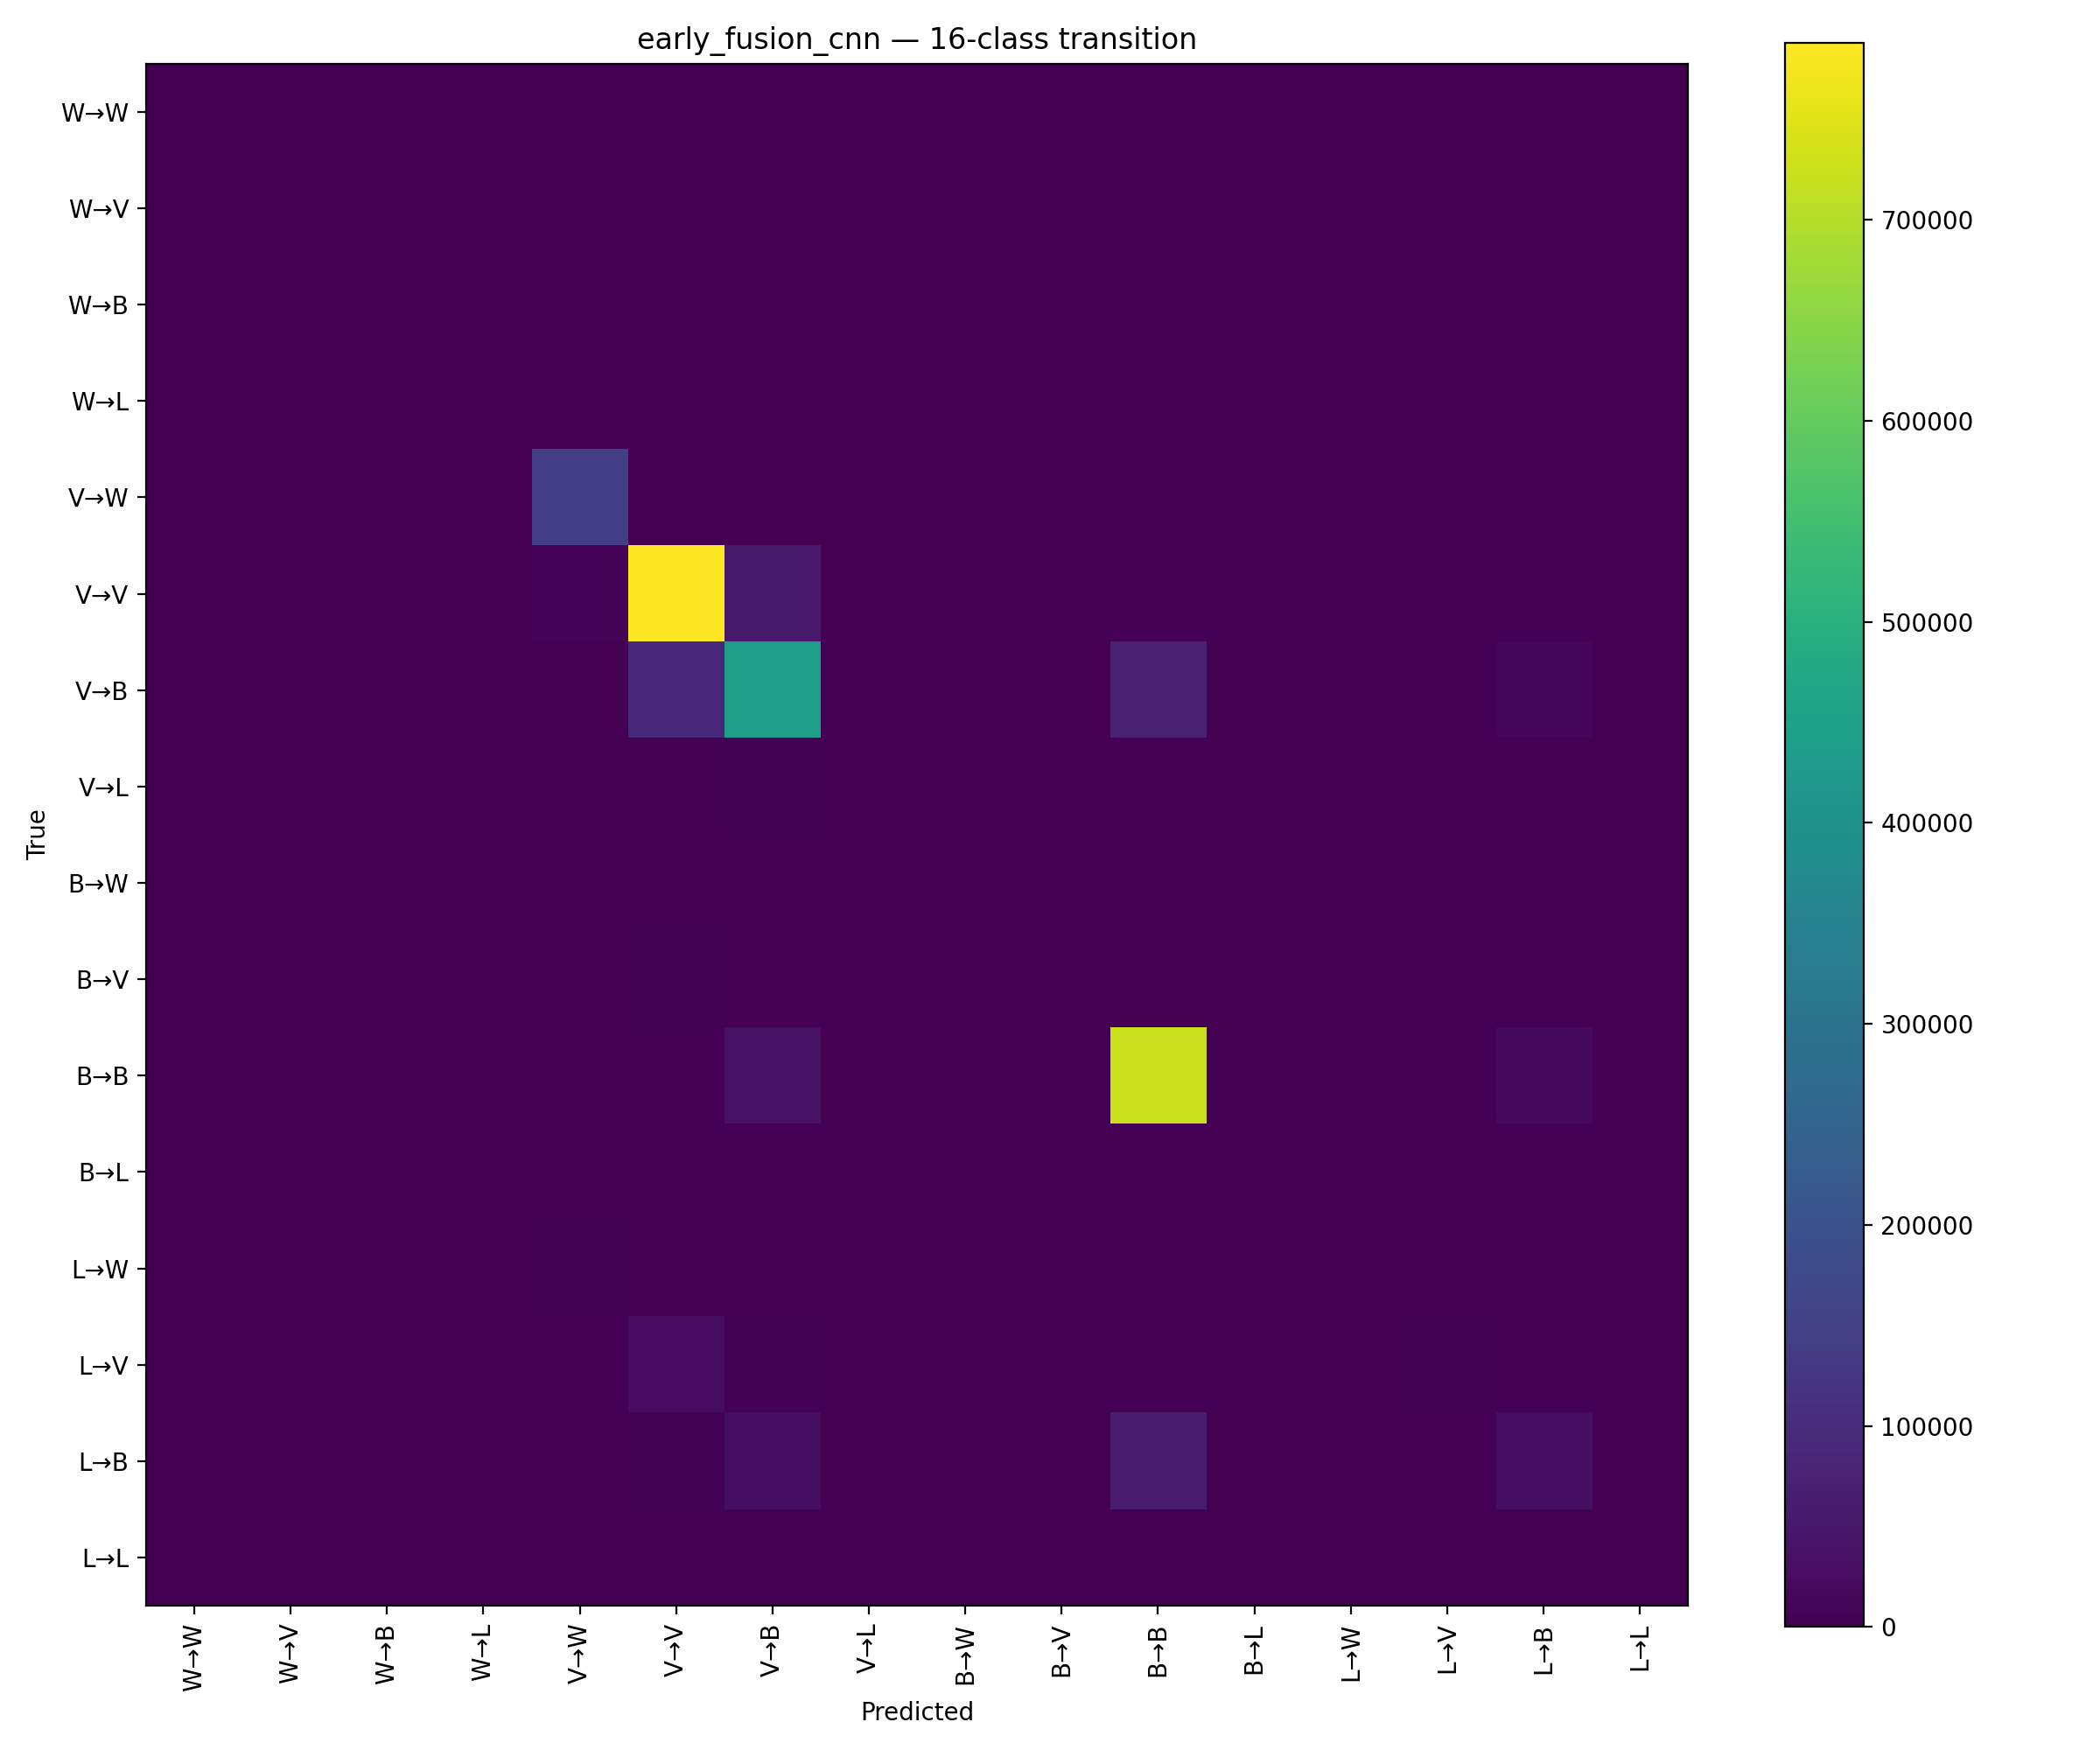

2-class change confusion matrix:


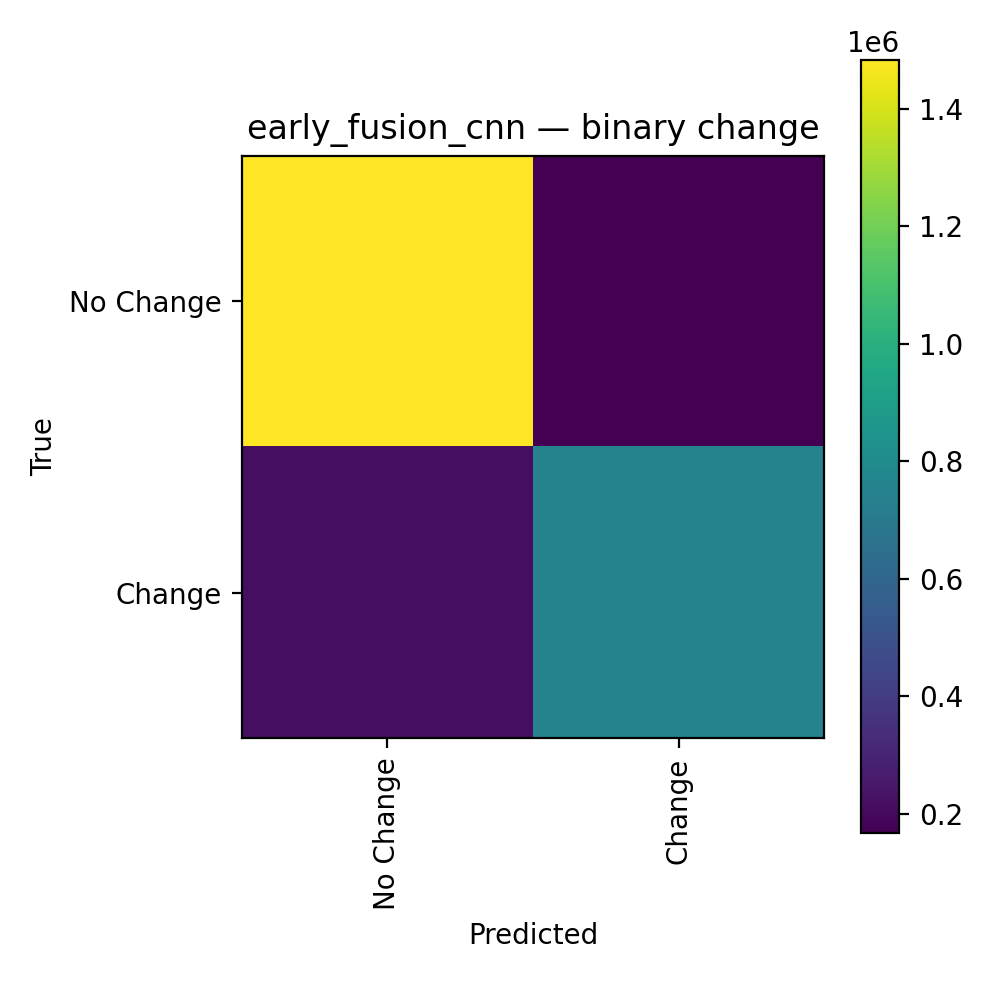


siamese_cnn
16-class transition confusion matrix:


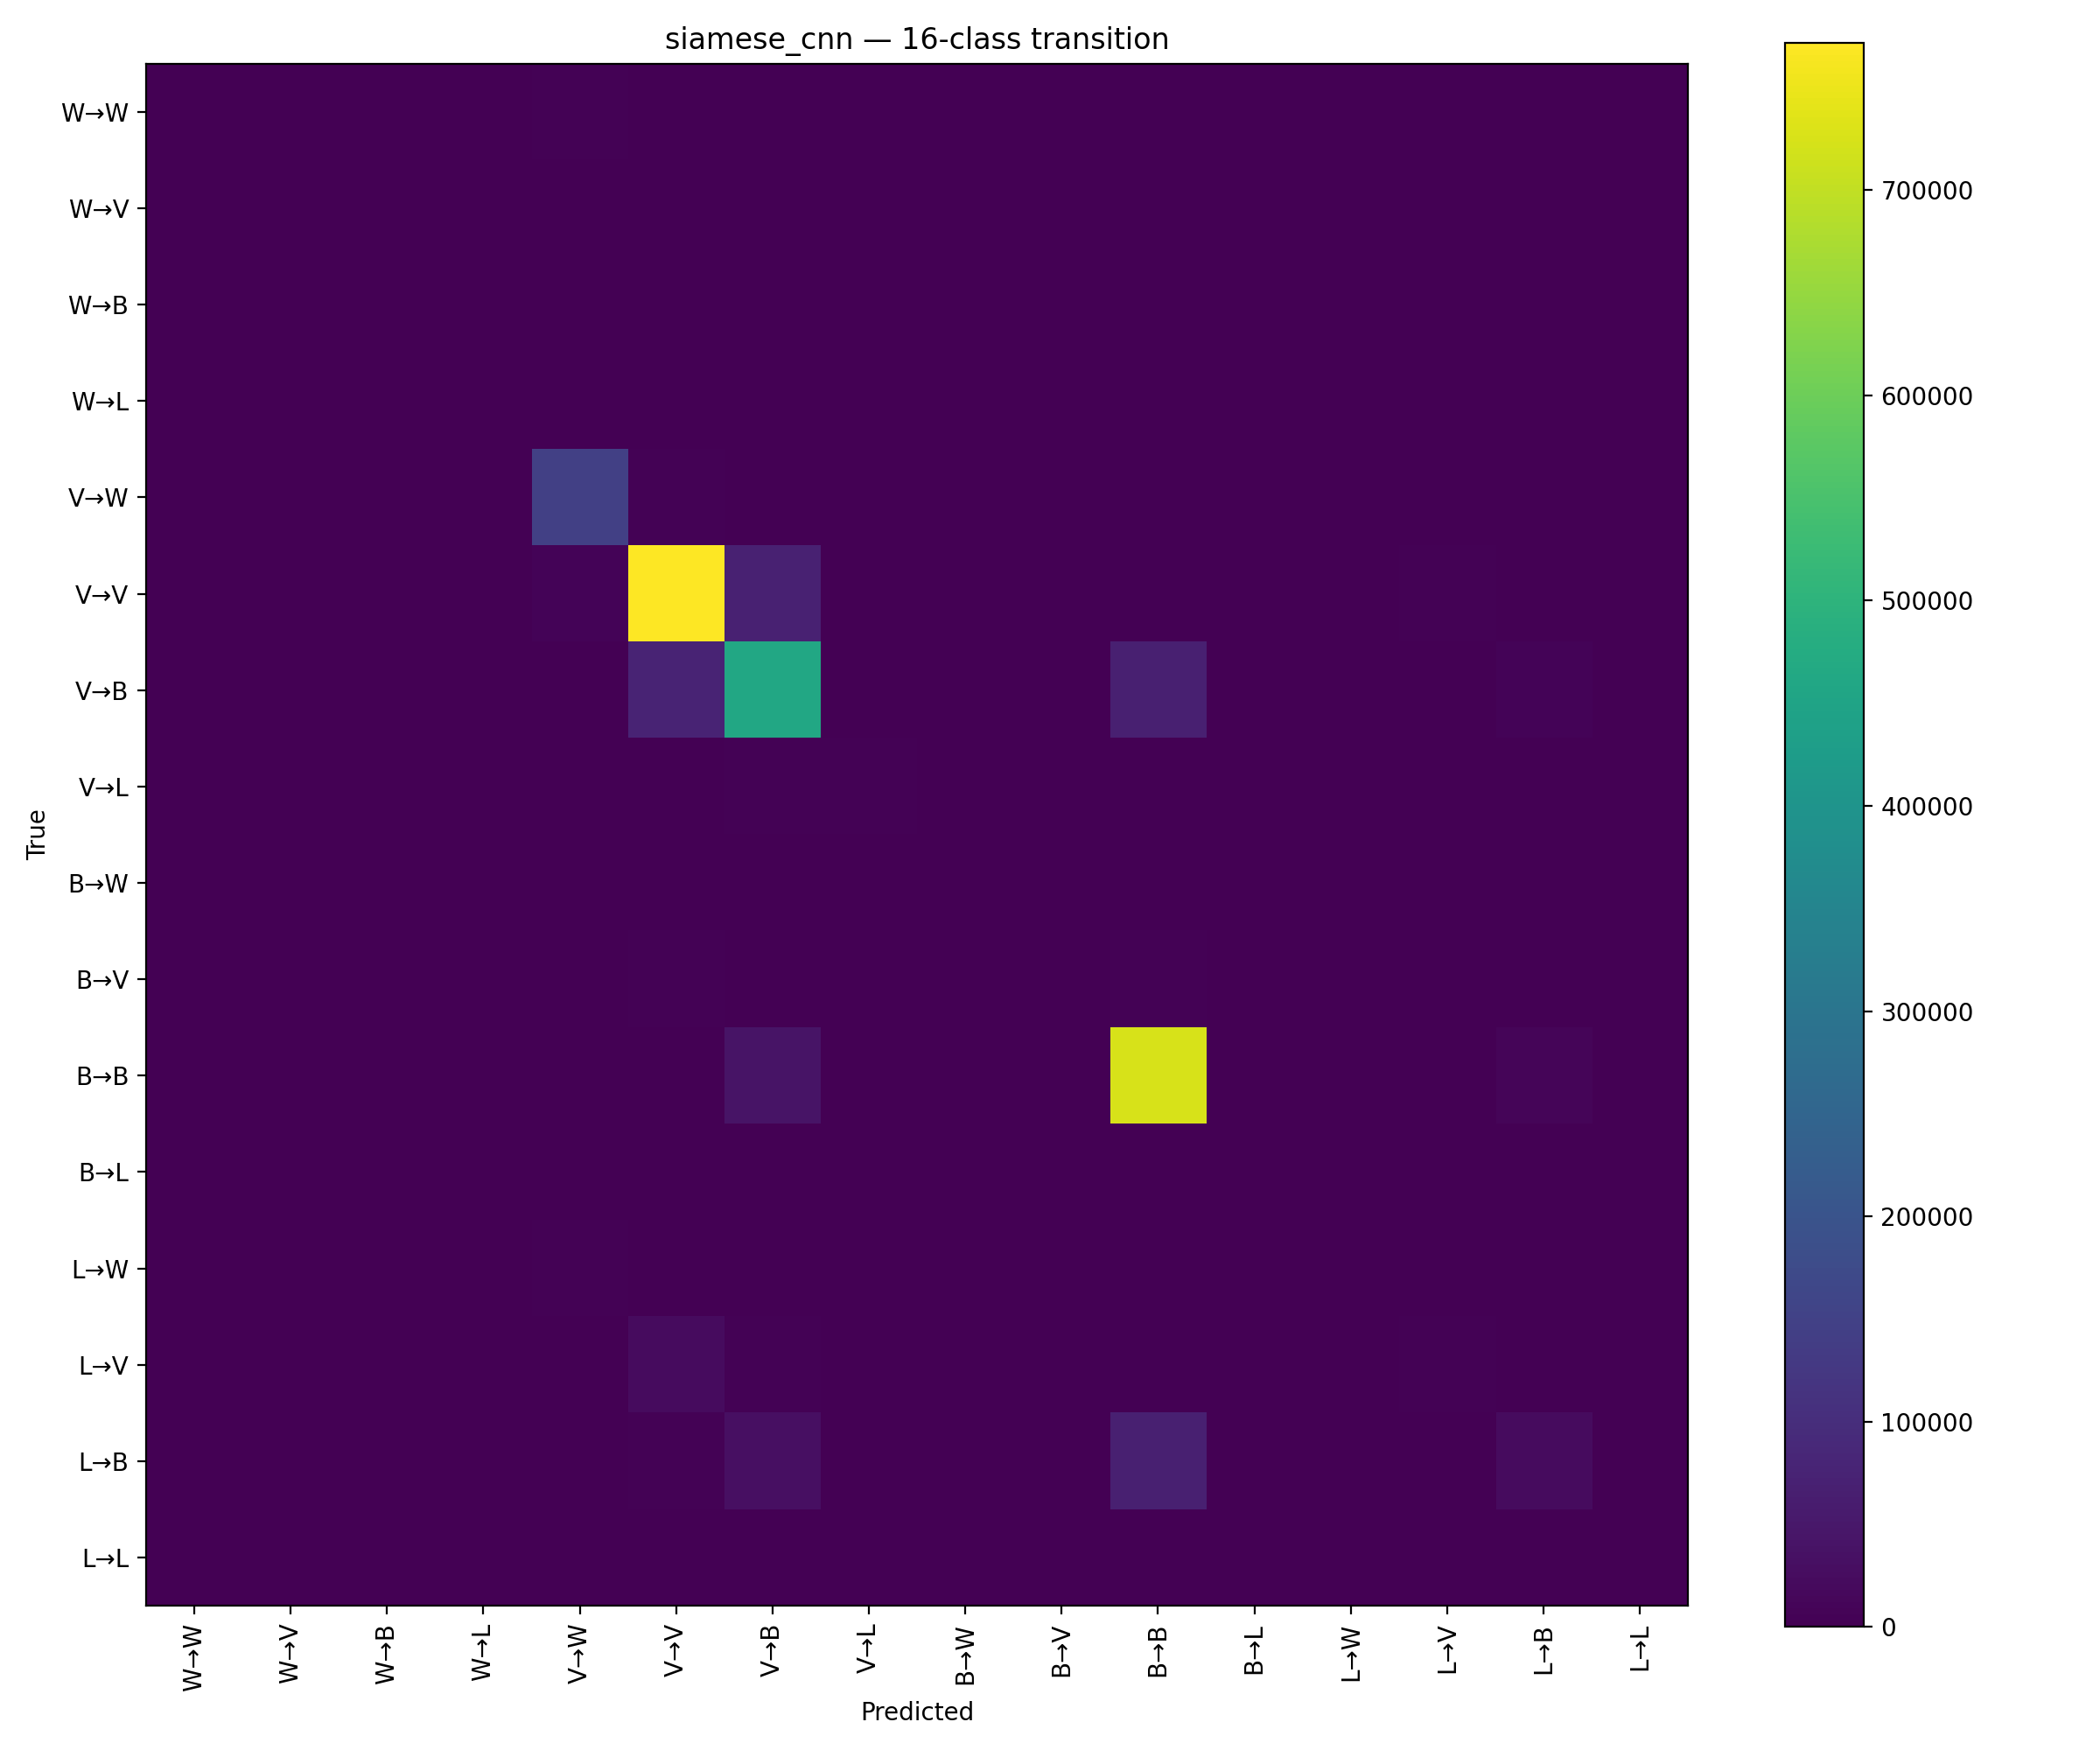

2-class change confusion matrix:


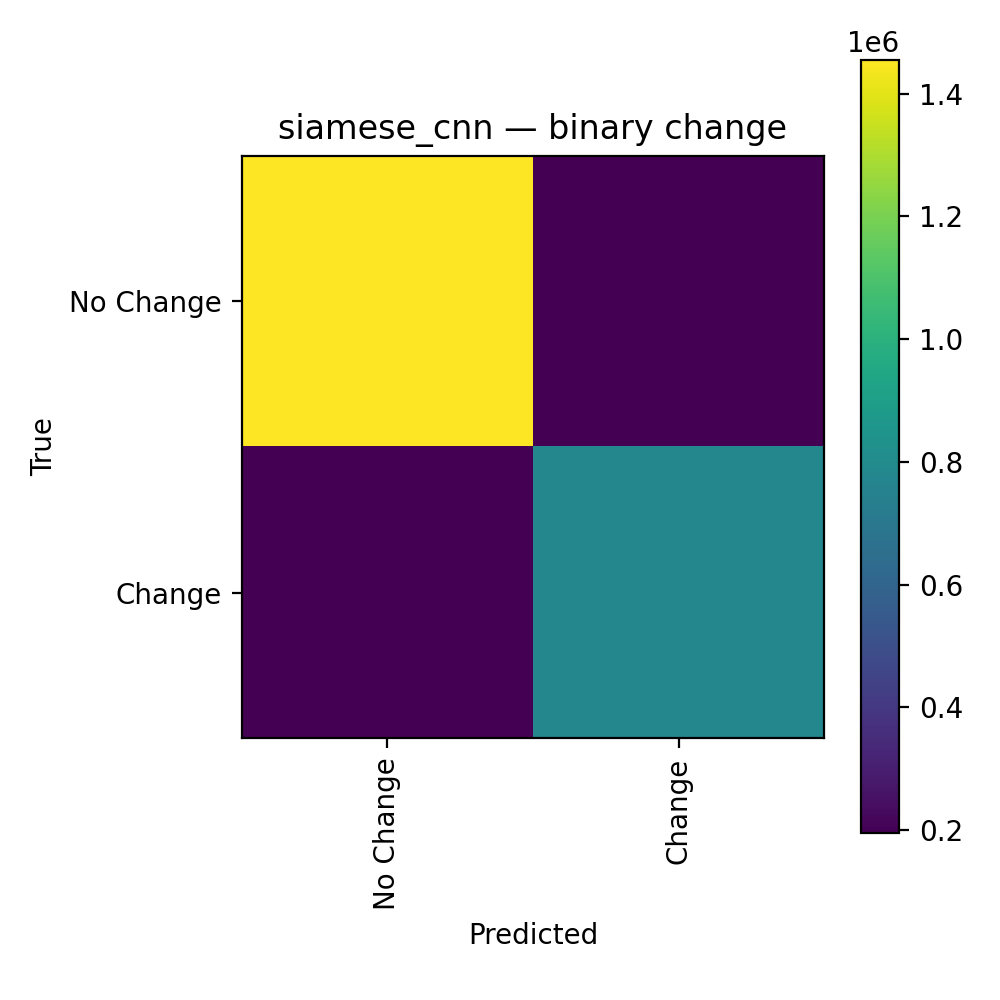


siamese_unet
16-class transition confusion matrix:


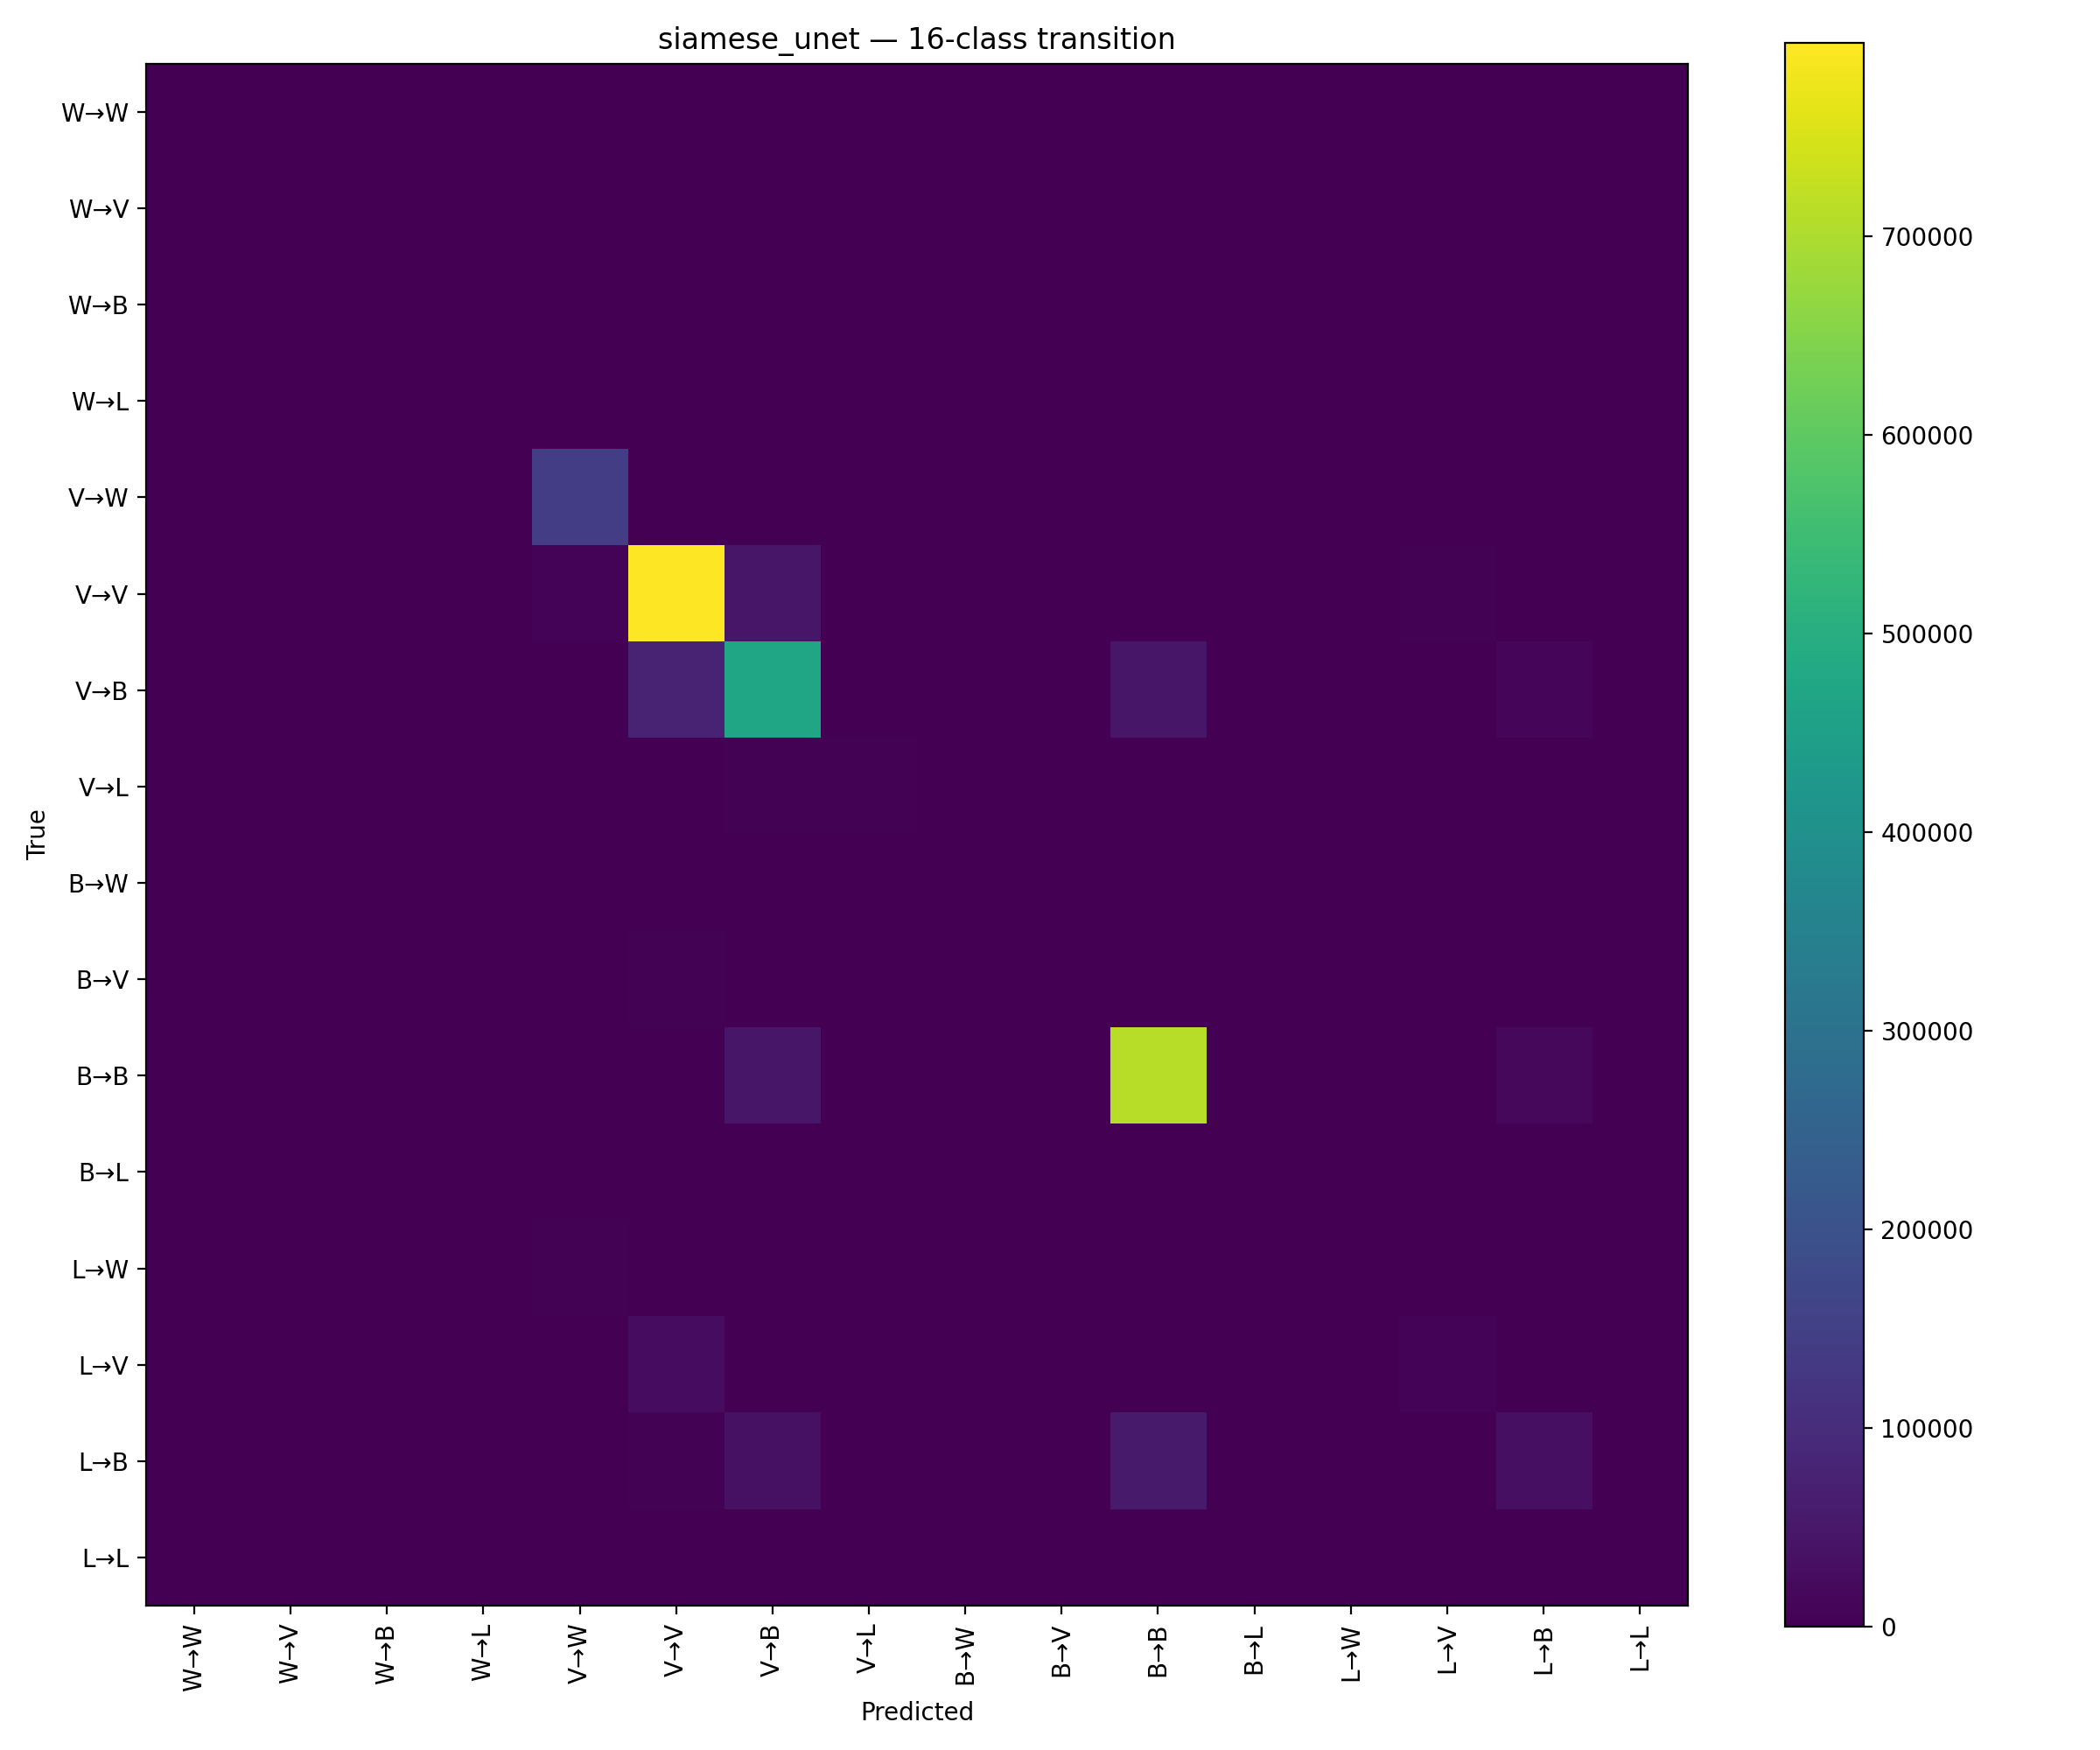

2-class change confusion matrix:


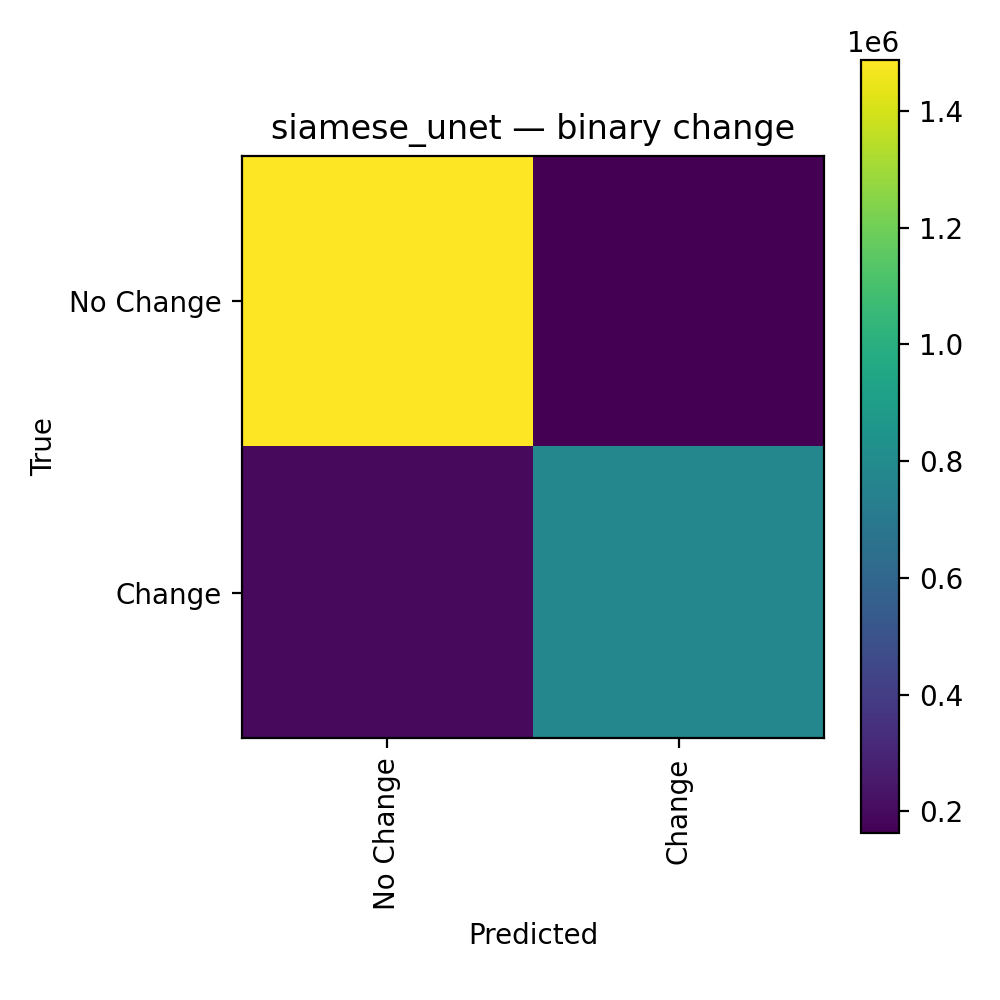

In [18]:
from IPython.display import display, Image
import os

for name in evaluations.keys():
    d = os.path.join(VIS, name)

    print("\n" + "="*60)
    print(name)
    print("="*60)

    print("16-class transition confusion matrix:")
    display(Image(
        filename=os.path.join(d, "transition_confusion_matrix.png")
    ))

    print("2-class change confusion matrix:")
    display(Image(
        filename=os.path.join(d, "change_confusion_matrix.png")
    ))

## Representative test examples

The same test examples are used for all models. The displayed RGB-like view is only for visualization; the models always receive all 9 channels.

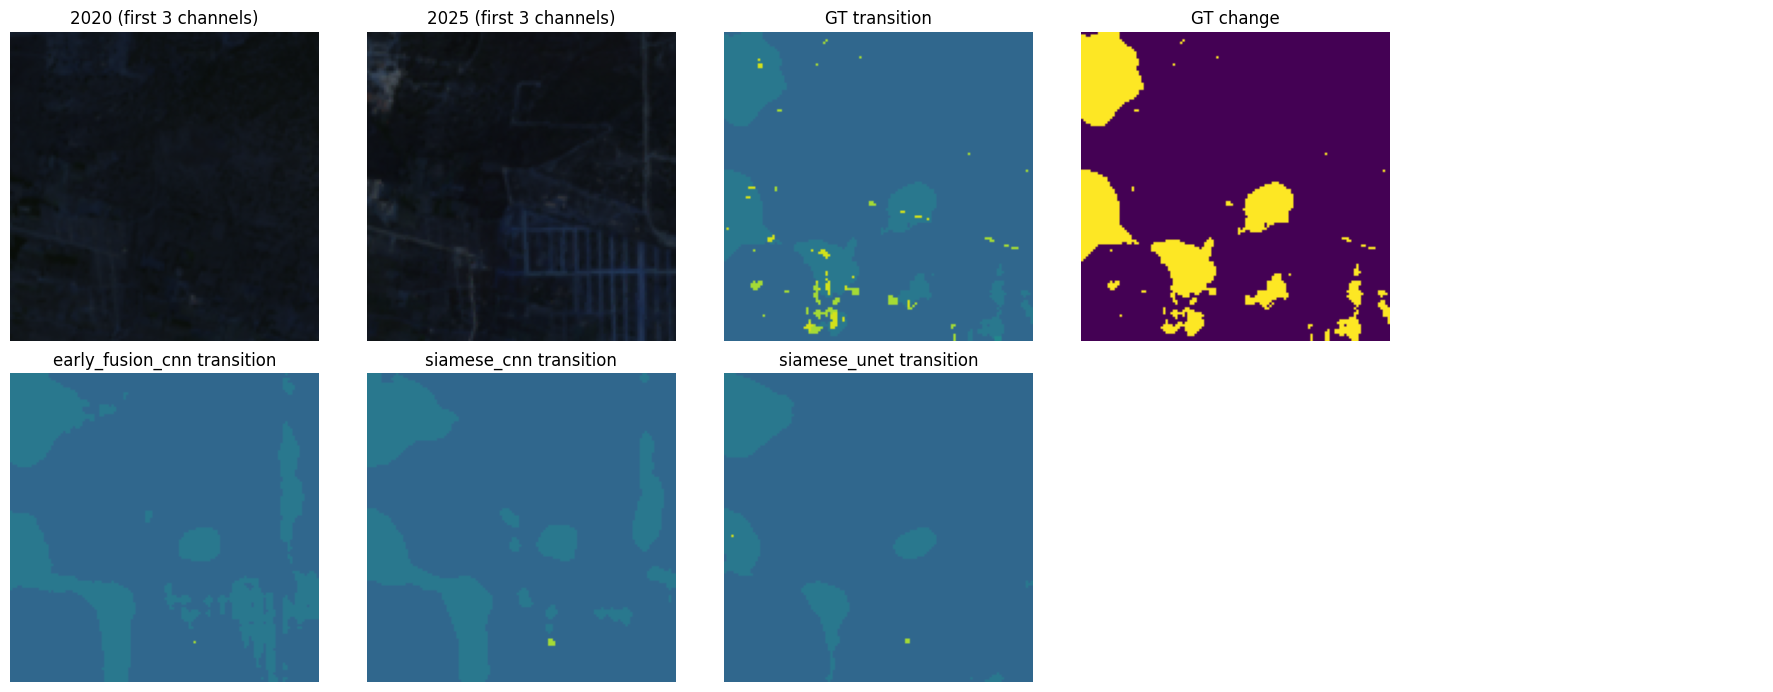

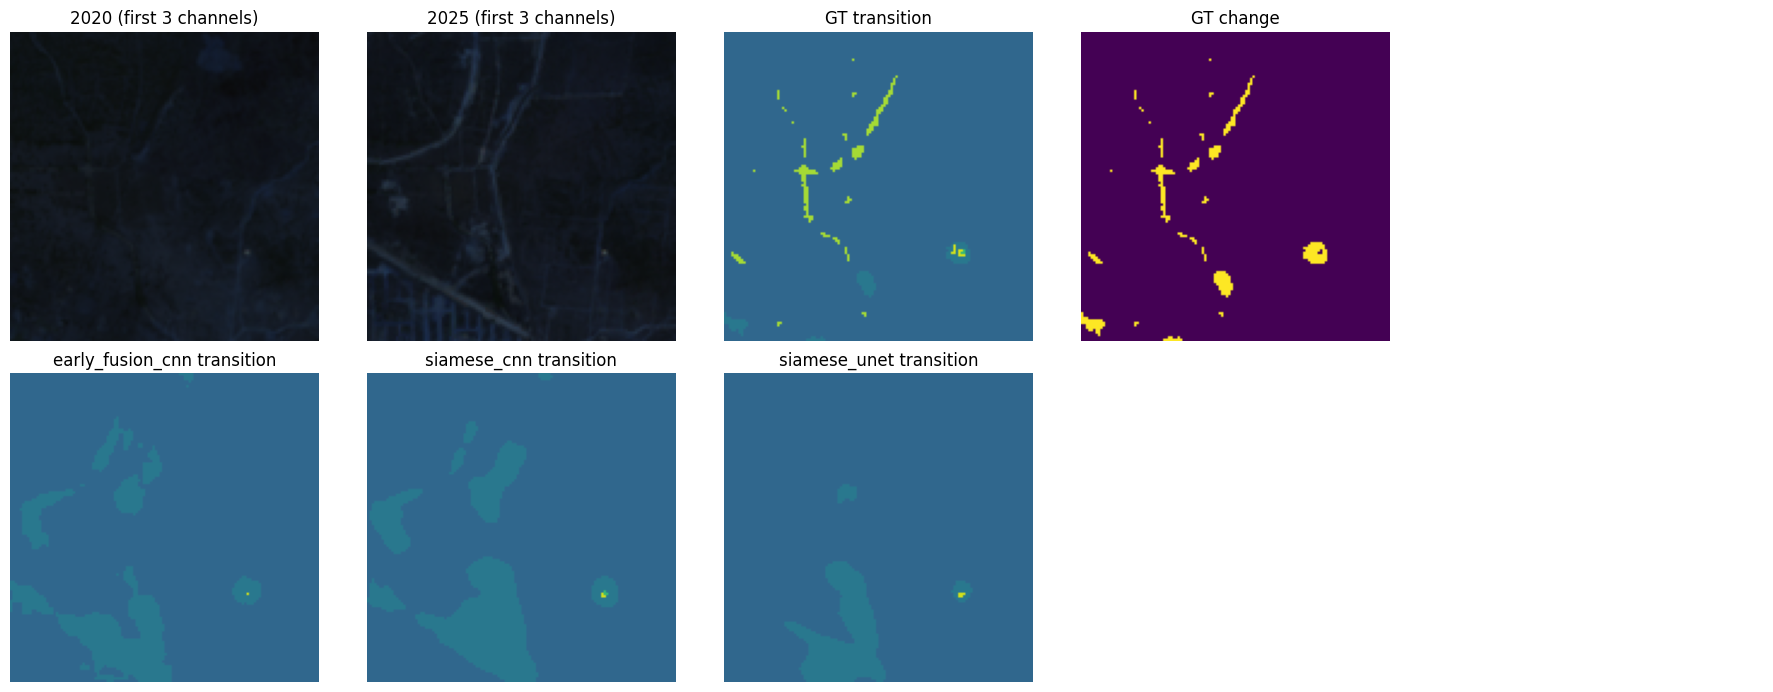

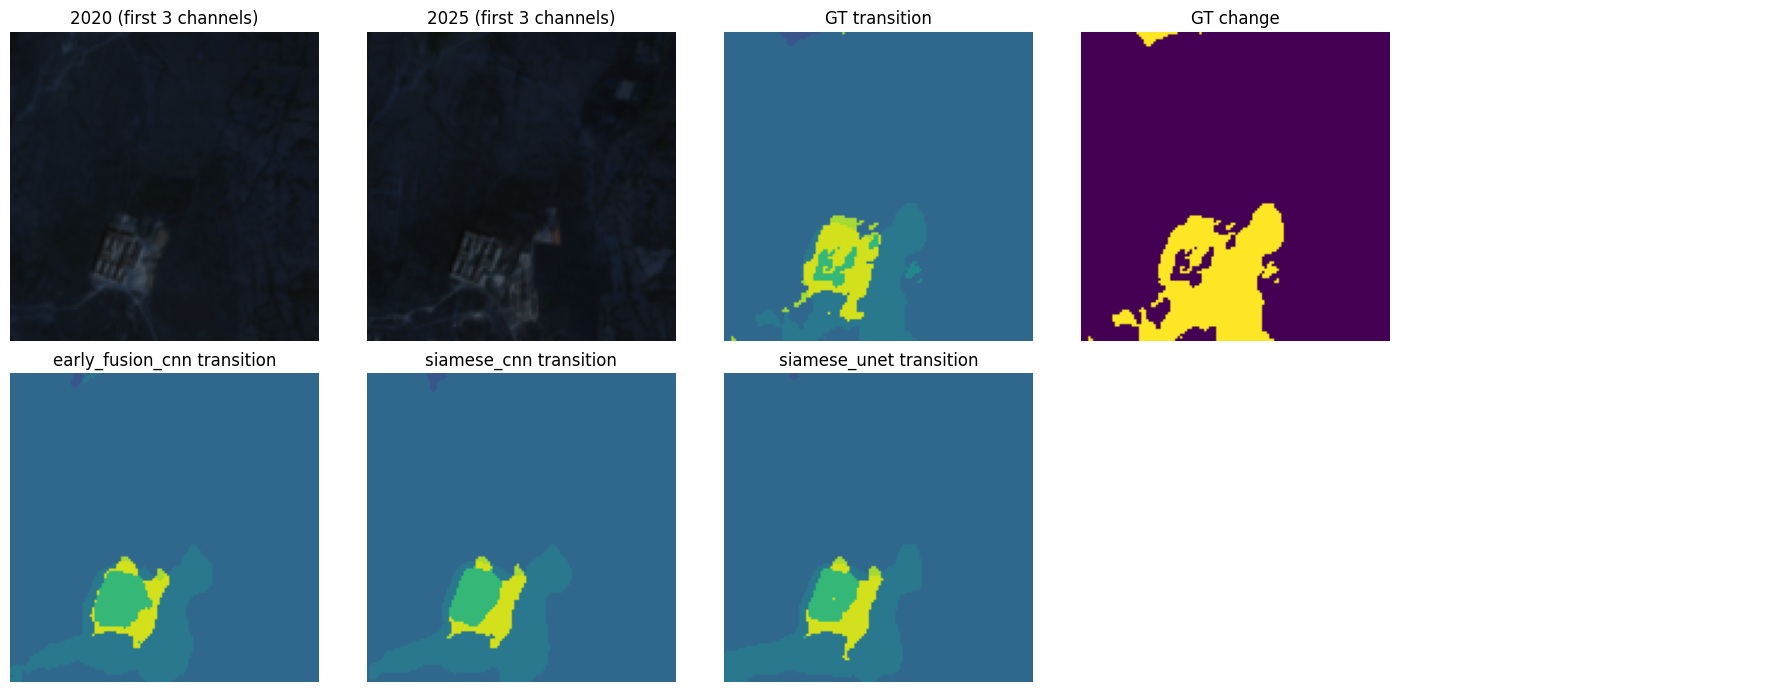

In [17]:
test_meta=metadata[metadata.split=='test'].reset_index(drop=True)
for k in range(min(3,len(test_meta))):
    fn=test_meta.loc[k,'filename']; x20,x25,yt,yc=load_patch(fn); fig,ax=plt.subplots(2,5,figsize=(18,7))
    ax[0,0].imshow(np.clip(x20[:,:,:3],0,1)); ax[0,0].set_title('2020 (first 3 channels)'); ax[0,1].imshow(np.clip(x25[:,:,:3],0,1)); ax[0,1].set_title('2025 (first 3 channels)'); ax[0,2].imshow(np.where(yt==255,np.nan,yt),vmin=0,vmax=15); ax[0,2].set_title('GT transition'); ax[0,3].imshow(np.where(yc==255,np.nan,yc),vmin=0,vmax=1); ax[0,3].set_title('GT change'); ax[0,4].axis('off')
    for j,name in enumerate(models):
        idx=k; pred=evaluations[name][1][idx]; ax[1,j].imshow(pred,vmin=0,vmax=15); ax[1,j].set_title(name+' transition')
    ax[1,3].axis('off'); ax[1,4].axis('off');
    for a in ax.flat: a.axis('off')
    fig.tight_layout(); fig.savefig(os.path.join(VIS,f'representative_{k:02d}.png'),dpi=180); plt.show(); plt.close(fig)

## Final checklist

- Same v4 dataset and split for all models
- 9 channels per date
- 16-class transition output `(128,128,16)`
- 2-class change output `(128,128,2)`
- Shared encoder weights in both Siamese baselines
- `255` ignored in training/evaluation
- Actual test metrics only
- Models, predictions, confusion matrices, metrics, and comparison table saved
- BT-SSSCNet remains separate